# DoubleDeflector Before Two Lenses: Differentiable Beam Shift Optimization

This notebook demonstrates a differentiable `DoubleDeflector` placed before two lenses.
We optimize `shift_x`, `shift_y`, `shift_balance_x`, `shift_balance_y` (with tilt commands fixed at zero) to hit a target sample-plane shift while keeping output angle near zero.

In [12]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optimistix as optx

from temgym_core.ray import Ray
from temgym_core.components import DoubleDeflector, Lens, Detector
from temgym_core.run import run_to_end
from temgym_core.plotting import plot_model, legacy_beam_plot_params

jax.config.update('jax_enable_x64', True)

## Geometry and Helper Builders

In [13]:
z0 = 0.0
z_def = 0.08
spacing = 0.02
z_lens1 = 0.24
z_lens2 = 0.40
z_sample = 0.56

f1 = 0.20
f2 = 0.23

ray0 = Ray(x=0.0, y=0.0, dx=0.0, dy=0.0, z=z0, pathlength=0.0)

def build_model_double(params):
    shift_x, shift_y, shift_balance_x, shift_balance_y = params
    return (
        DoubleDeflector(
            z=z_def,
            spacing=spacing,
            shift_x=shift_x,
            shift_y=shift_y,
            shift_balance_x=shift_balance_x,
            shift_balance_y=shift_balance_y,
        ),
        Lens(z=z_lens1, focal_length=f1),
        Lens(z=z_lens2, focal_length=f2),
        Detector(z=z_sample, pixel_size=(1e-6, 1e-6), shape=(64, 64)),
    )


def run_sample(params, model_builder):
    return run_to_end(ray0, model_builder(params))

## Differentiable Optimization: Target Position with Near-Zero Angle

In [14]:
target_xy = jnp.array([3.0e-4, -2.0e-4], dtype=jnp.float64)

def residual_physical(params):
    out = run_sample(params, build_model_double)
    return jnp.array([
        (out.x - target_xy[0]) / 1e-4,
        (out.y - target_xy[1]) / 1e-4,
        out.dx / 5e-5,
        out.dy / 5e-5,
    ], dtype=jnp.float64)


def bounded_logistic_to_physical(u, bounds_arr):
    b = jnp.asarray(bounds_arr, dtype=jnp.float64)
    lo = b[:, 0]
    hi = b[:, 1]
    return lo + (hi - lo) * jax.nn.sigmoid(u)


def bounded_logit_from_physical(x, bounds_arr):
    b = np.asarray(bounds_arr, dtype=float)
    lo = b[:, 0]
    hi = b[:, 1]
    s = np.clip((np.asarray(x, dtype=float) - lo) / (hi - lo), 1e-9, 1.0 - 1e-9)
    return np.log(s) - np.log1p(-s)


@jax.jit
def residual_unbounded_u(u, args):
    bounds_arr, = args
    x = bounded_logistic_to_physical(u, bounds_arr)
    return residual_physical(x)


x0 = np.array([1.0e-4, -1.0e-4, 1.0, 1.0], dtype=float)

bounds_arr = np.array([
    [-1e-2, 1e-2],
    [-1e-2, 1e-2],
    [0.2, 3.0],
    [0.2, 3.0],
], dtype=float)

x0 = np.clip(x0, bounds_arr[:, 0], bounds_arr[:, 1])
u0 = bounded_logit_from_physical(x0, bounds_arr)

r0 = np.asarray(residual_physical(jnp.asarray(x0, dtype=jnp.float64)))
loss_init = float(r0 @ r0)

solver = optx.LevenbergMarquardt(rtol=1e-12, atol=1e-12)
sol = optx.root_find(
    residual_unbounded_u,
    solver,
    y0=jnp.asarray(u0, dtype=jnp.float64),
    args=(bounds_arr,),
    options={'jac': 'fwd'},
    max_steps=800,
    throw=False,
)

u_star = np.asarray(sol.value, dtype=float)
x_star = np.asarray(bounded_logistic_to_physical(u_star, bounds_arr), dtype=float)

params_opt = jnp.asarray(x_star, dtype=jnp.float64)
rf = np.asarray(residual_physical(params_opt))
loss_final = float(rf @ rf)

loss_history = [loss_init, loss_final]

print('Solver result:', str(sol.result))
print('Num steps:', int(np.asarray(sol.stats.get('num_steps', 0))))
print(f'Initial loss: {loss_init:.6f}')
print(f'Final loss:   {loss_final:.6f}')
print('Optimized params [shift_x, shift_y, shift_balance_x, shift_balance_y]:')
print(np.asarray(params_opt))


Solver result: optimistix._solution.RESULTS<>
Num steps: 33
Initial loss: 13.258509
Final loss:   0.000000
Optimized params [shift_x, shift_y, shift_balance_x, shift_balance_y]:
[-0.00776087  0.00517391  1.22689076  1.22689076]


In [15]:
def pivot_distance(spacing_val, shift_balance_val, eps=1e-12):
    if abs(float(shift_balance_val) - 1.0) < eps:
        return np.inf
    return float(spacing_val / (float(shift_balance_val) - 1.0))

out_opt = run_sample(params_opt, build_model_double)

d_pivot_x = pivot_distance(spacing, params_opt[2])
d_pivot_y = pivot_distance(spacing, params_opt[3])

print(f'Final sample x,y:  ({float(out_opt.x):+.6e}, {float(out_opt.y):+.6e}) m')
print(f'Target sample x,y: ({float(target_xy[0]):+.6e}, {float(target_xy[1]):+.6e}) m')
print(f'Final sample dx,dy: ({float(out_opt.dx):+.6e}, {float(out_opt.dy):+.6e}) rad')
print(f'Inferred d_pivot_x = {d_pivot_x:+.6e} m')
print(f'Inferred d_pivot_y = {d_pivot_y:+.6e} m')

Final sample x,y:  (+3.000000e-04, -2.000000e-04) m
Target sample x,y: (+3.000000e-04, -2.000000e-04) m
Final sample dx,dy: (+6.505213e-19, +2.168404e-19) rad
Inferred d_pivot_x = +8.814815e-02 m
Inferred d_pivot_y = +8.814815e-02 m


## Tilt Invariance Check Over Many Drives

With fixed optimized shift balances, we sweep many shift command values and verify sample-plane tilt remains ~0.

In [16]:
def run_with_fixed_balance(shift_x, shift_y):
    params = jnp.array([
        shift_x,
        shift_y,
        params_opt[2],
        params_opt[3],
    ], dtype=jnp.float64)
    return run_sample(params, build_model_double)

# Axis-wise sweeps
shift_vals = np.linspace(-8e-3, 8e-3, 81)
dx_from_xshift = []
dy_from_yshift = []

for d in shift_vals:
    out_x = run_with_fixed_balance(float(d), 0.0)
    dx_from_xshift.append(float(out_x.dx))

    out_y = run_with_fixed_balance(0.0, float(d))
    dy_from_yshift.append(float(out_y.dy))

dx_from_xshift = np.asarray(dx_from_xshift)
dy_from_yshift = np.asarray(dy_from_yshift)

# Random combined shifts
rng = np.random.default_rng(0)
combo = rng.uniform(-8e-3, 8e-3, size=(200, 2))
combo_tilts = []
for dx_d, dy_d in combo:
    out = run_with_fixed_balance(float(dx_d), float(dy_d))
    combo_tilts.append([float(out.dx), float(out.dy)])
combo_tilts = np.asarray(combo_tilts)

max_abs_dx_axis = np.max(np.abs(dx_from_xshift))
max_abs_dy_axis = np.max(np.abs(dy_from_yshift))
max_abs_dx_combo = np.max(np.abs(combo_tilts[:, 0]))
max_abs_dy_combo = np.max(np.abs(combo_tilts[:, 1]))

print(f'Max |dx| (x-shift sweep): {max_abs_dx_axis:.3e} rad')
print(f'Max |dy| (y-shift sweep): {max_abs_dy_axis:.3e} rad')
print(f'Max |dx| (random combos): {max_abs_dx_combo:.3e} rad')
print(f'Max |dy| (random combos): {max_abs_dy_combo:.3e} rad')

tilt_tol = 1e-12
assert max_abs_dx_axis < tilt_tol
assert max_abs_dy_axis < tilt_tol
assert max_abs_dx_combo < tilt_tol
assert max_abs_dy_combo < tilt_tol
print(f'Passed: tilt remains below {tilt_tol:.1e} rad for tested drive range.')


Max |dx| (x-shift sweep): 8.674e-19 rad
Max |dy| (y-shift sweep): 6.505e-19 rad
Max |dx| (random combos): 1.301e-18 rad
Max |dy| (random combos): 8.674e-19 rad
Passed: tilt remains below 1.0e-12 rad for tested drive range.


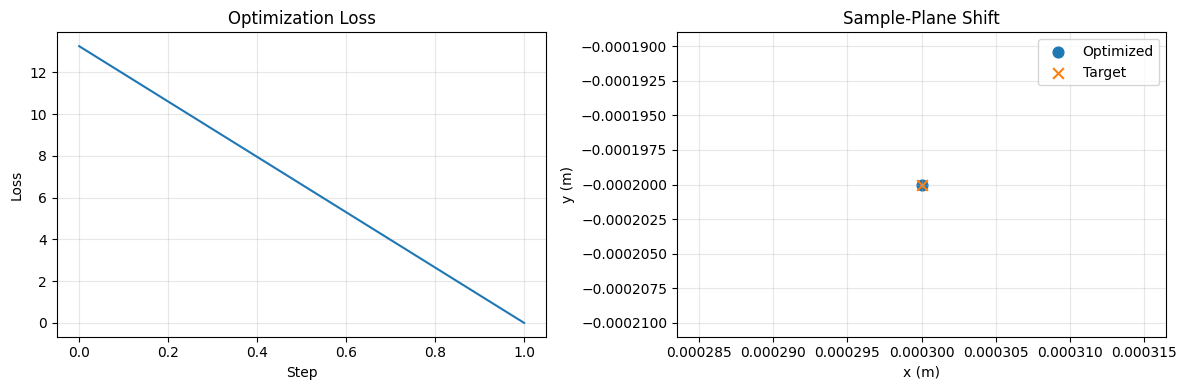

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set_title('Optimization Loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(float(out_opt.x), float(out_opt.y), label='Optimized', s=60)
axes[1].scatter(float(target_xy[0]), float(target_xy[1]), label='Target', s=60, marker='x')
axes[1].set_title('Sample-Plane Shift')
axes[1].set_xlabel('x (m)')
axes[1].set_ylabel('y (m)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

(<Figure size 600x1000 with 1 Axes>, <Axes: >)

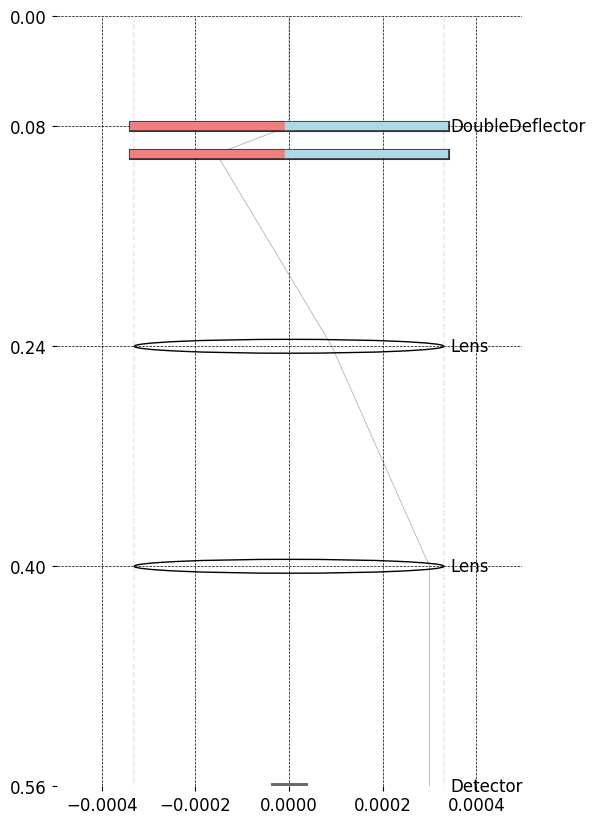

In [18]:
components_opt = build_model_double(params_opt)
plot_model(components_opt, rays=ray0)

## GIFs: Tilt About Sample Center and Shifted Sample Point

This section creates two side-view GIFs using a shared helper and a JAX root-finding calibration:
- Tilt about sample center (`x_sample \approx 0` while angle changes).
- Tilt about a shifted sample point (`x_sample \approx x_{target}` while angle changes).

The pivot controls are solved through the full two-lens path using `optimistix.root_find` (Levenberg-Marquardt), not a free-space closed-form approximation.

Center-pivot fit:
  shift_x = +2.523218e-13 mrad
  shift_balance_x = +1.000380e+00
  tilt_balance_x = +8.599554e-01
  max |x_sample| over fit scales = 2.279e-07 m
Shifted-pivot fit:
  shift_x = +1.064778e-02 mrad
  shift_balance_x = +7.263243e-01
  tilt_balance_x = +8.595041e-01
  max |x_sample - x_target| over fit scales = 7.944e-07 m
Saved: double_deflector_tilt_about_sample.gif


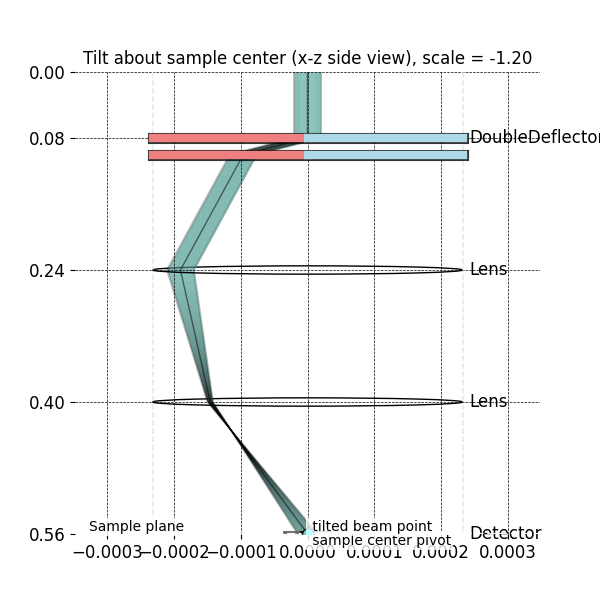

Saved: double_deflector_tilt_about_shifted_sample_point.gif


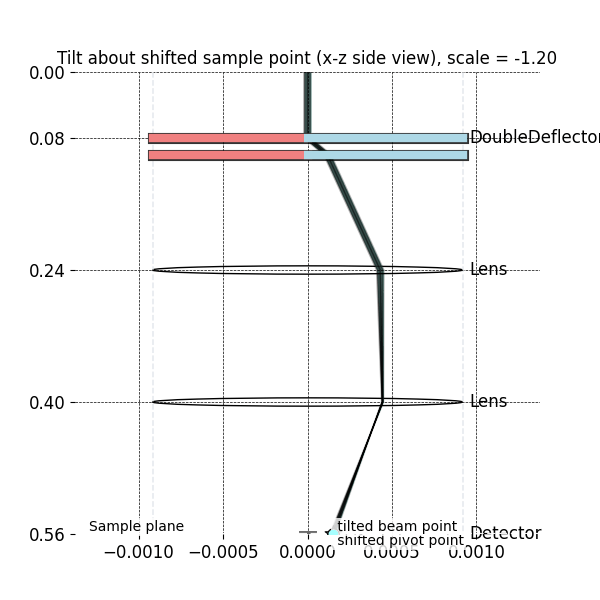

In [ ]:
from dataclasses import replace
from pathlib import Path
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
from temgym_core.run import run_iter_vmapped

plt.rcParams['animation.html'] = 'none'

# 25-ray bundle for side-view visualization
bundle_radius = 2.0e-5
x_bundle = np.linspace(-bundle_radius, bundle_radius, 25)
rays_bundle = Ray(
    x=x_bundle,
    y=np.zeros_like(x_bundle),
    dx=np.zeros_like(x_bundle),
    dy=np.zeros_like(x_bundle),
    z=np.zeros_like(x_bundle) + float(ray0.z),
    pathlength=np.zeros_like(x_bundle),
)

scales_fwd = np.linspace(-1.2, 1.2, 61)
scales = np.concatenate([scales_fwd, scales_fwd[-2:0:-1]])
scales_fit = np.array([-1.2, -0.8, -0.4, 0.0, 0.4, 0.8, 1.2], dtype=float)

plot_style = legacy_beam_plot_params(
    fill_color='#7BFFF0',
    fill_alpha=0.55,
    solid_beam=True,
)

def output_dir():
    p = Path('examples/basic_examples')
    return p if p.exists() else Path('.')

def detector_half_width_x(components):
    det_rx = 0.0
    for c in components:
        if isinstance(c, Detector):
            try:
                det_rx = max(det_rx, float(c.pixel_size[1] * c.shape[1] / 2.0))
            except Exception:
                det_rx = max(det_rx, float(c.pixel_size[0] * c.shape[0] / 2.0))
    return det_rx

def bundle_abs_x_max(components):
    steps = (rays_bundle,) + tuple(run_iter_vmapped(rays_bundle, components))
    return max(float(np.max(np.abs(np.asarray(r.x)))) for r in steps)

def sample_x_for_controls(shift_x, tilt_x, shift_balance_x, tilt_balance_x):
    components = (
        DoubleDeflector(
            z=z_def,
            spacing=spacing,
            shift_x=float(shift_x),
            shift_y=0.0,
            tilt_x=float(tilt_x),
            tilt_y=0.0,
            shift_balance_x=float(shift_balance_x),
            shift_balance_y=1.0,
            tilt_balance_x=float(tilt_balance_x),
            tilt_balance_y=1.0,
        ),
        Lens(z=z_lens1, focal_length=f1),
        Lens(z=z_lens2, focal_length=f2),
        Detector(z=z_sample, pixel_size=(1e-6, 1e-6), shape=(64, 64)),
    )
    out = run_to_end(ray0, components)
    return jnp.asarray(out.x, dtype=jnp.float64)

def sample_intersection_x(model_components):
    out = run_to_end(ray0, model_components)
    return float(out.x)

def make_sideview_gif(
    model_for_scale,
    title_prefix,
    filename,
    pivot_x_m,
    pivot_label,
    fps=15,
):
    global_beam_x = 0.0
    sample_hit_x = []
    for s in scales:
        components = model_for_scale(float(s))
        global_beam_x = max(global_beam_x, bundle_abs_x_max(components))
        sample_hit_x.append(sample_intersection_x(components))

    global_detector_x = detector_half_width_x(model_for_scale(float(scales[0])))
    global_hit_x = max(np.max(np.abs(np.asarray(sample_hit_x))), abs(float(pivot_x_m)))
    fixed_xmax = max(global_beam_x, global_detector_x, global_hit_x, float(np.finfo(float).eps))
    plot_style_fixed = replace(plot_style, fixed_xmax=fixed_xmax)

    with plt.ioff():
        fig_probe, ax_probe = plt.subplots(figsize=(6.0, 6.0))
        plot_model(
            model_for_scale(float(scales[0])),
            rays=rays_bundle,
            plot_params=plot_style_fixed,
            band_mode='fill',
            ax=ax_probe,
        )
        fixed_xlim = ax_probe.get_xlim()
        fixed_ylim = ax_probe.get_ylim()
        plt.close(fig_probe)

        fig_anim, ax_anim = plt.subplots(figsize=(6.0, 6.0))

        def _annotate_reference_points(frame_idx):
            beam_x = sample_hit_x[frame_idx]

            ax_anim.axhline(
                y=float(z_sample),
                color='white',
                linestyle='--',
                linewidth=1.6,
                alpha=0.95,
                zorder=1500,
            )
            ax_anim.text(
                fixed_xlim[0] + 0.03 * (fixed_xlim[1] - fixed_xlim[0]),
                float(z_sample),
                'Sample plane',
                va='bottom',
                ha='left',
                fontsize=10,
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5),
                zorder=2001,
            )

            ax_anim.scatter(
                [float(pivot_x_m)],
                [float(z_sample)],
                marker='*',
                s=160,
                color='yellow',
                edgecolors='black',
                linewidths=0.8,
                zorder=2002,
            )
            ax_anim.text(
                float(pivot_x_m),
                float(z_sample),
                f' {pivot_label}',
                va='top',
                ha='left',
                fontsize=10,
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5),
                zorder=2003,
            )

            ax_anim.scatter(
                [float(beam_x)],
                [float(z_sample)],
                marker='o',
                s=70,
                color='cyan',
                edgecolors='black',
                linewidths=0.8,
                zorder=2004,
            )
            ax_anim.text(
                float(beam_x),
                float(z_sample),
                ' tilted beam point',
                va='bottom',
                ha='left',
                fontsize=10,
                color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5),
                zorder=2005,
            )

        def _update(frame_idx):
            ax_anim.clear()
            s = float(scales[frame_idx])
            plot_model(
                model_for_scale(s),
                rays=rays_bundle,
                plot_params=plot_style_fixed,
                band_mode='fill',
                ax=ax_anim,
            )
            _annotate_reference_points(frame_idx)
            ax_anim.set_xlim(fixed_xlim)
            ax_anim.set_ylim(fixed_ylim)
            ax_anim.set_title(f'{title_prefix}, scale = {s:+.2f}')
            return []

        anim = FuncAnimation(fig_anim, _update, frames=len(scales), interval=70, blit=False)
        out_dir = output_dir()
        out_dir.mkdir(parents=True, exist_ok=True)
        gif_path = out_dir / filename
        anim.save(gif_path, writer=PillowWriter(fps=fps))
        plt.close(fig_anim)

    return gif_path

# Solve pivot controls through the full two-lens path with a root solver.
base_tilt_x = 4.0e-3
x_target_shifted = 1.5e-4

fit_bounds = np.array([
    [-2e-2, 2e-2],
    [0.1, 3.0],
    [0.1, 3.0],
], dtype=float)

def residual_with_target(params_phys, x_target):
    shift_x, shift_balance_x, tilt_balance_x = (float(params_phys[0]), float(params_phys[1]), float(params_phys[2]))
    vals = [
        float(
            sample_x_for_controls(
                shift_x=shift_x,
                tilt_x=s * base_tilt_x,
                shift_balance_x=shift_balance_x,
                tilt_balance_x=tilt_balance_x,
            )
        ) - float(x_target)
        for s in scales_fit
    ]
    return np.asarray(vals, dtype=float)

def solve_pivot_root(x_target, x0_phys):
    x0_phys = np.clip(np.asarray(x0_phys, dtype=float), fit_bounds[:, 0], fit_bounds[:, 1])
    u0 = bounded_logit_from_physical(x0_phys, fit_bounds)

    def residual_u(u, args):
        x_target_local, = args
        x_phys = bounded_logistic_to_physical(u, fit_bounds)
        shift_x, shift_balance_x, tilt_balance_x = x_phys
        vals = jnp.array([
            sample_x_for_controls(
                shift_x=shift_x,
                tilt_x=s * base_tilt_x,
                shift_balance_x=shift_balance_x,
                tilt_balance_x=tilt_balance_x,
            ) - x_target_local
            for s in scales_fit
        ], dtype=jnp.float64)
        return vals / 1e-6

    sol = optx.root_find(
        residual_u,
        optx.LevenbergMarquardt(rtol=1e-12, atol=1e-12),
        y0=jnp.asarray(u0, dtype=jnp.float64),
        args=(jnp.asarray(x_target, dtype=jnp.float64),),
        options={'jac': 'fwd'},
        max_steps=800,
        throw=False,
    )

    params_star = np.asarray(bounded_logistic_to_physical(sol.value, fit_bounds), dtype=float)
    return params_star, sol

center_params, center_sol = solve_pivot_root(
    x_target=0.0,
    x0_phys=np.array([0.0, 1.0, 1.0], dtype=float),
)
shift_x_center, shift_balance_center, tilt_balance_center = [float(v) for v in center_params]

shifted_params, shifted_sol = solve_pivot_root(
    x_target=x_target_shifted,
    x0_phys=np.array([
        x_target_shifted / max(float(spacing), 1e-12),
        shift_balance_center,
        tilt_balance_center,
    ], dtype=float),
)
shift_x_shifted, shift_balance_shifted, tilt_balance_shifted = [float(v) for v in shifted_params]

center_err = float(np.max(np.abs(residual_with_target(center_params, 0.0))))
shifted_err = float(np.max(np.abs(residual_with_target(shifted_params, x_target_shifted))))

print('Center-pivot root solve:')
print(f'  status = {str(center_sol.result)}')
print(f"  num_steps = {int(np.asarray(center_sol.stats.get('num_steps', 0)))}")
print(f'  shift_x = {shift_x_center:+.6e} mrad')
print(f'  shift_balance_x = {shift_balance_center:+.6e}')
print(f'  tilt_balance_x = {tilt_balance_center:+.6e}')
print(f'  max |x_sample| over fit scales = {center_err:.3e} m')

print('Shifted-pivot root solve:')
print(f'  status = {str(shifted_sol.result)}')
print(f"  num_steps = {int(np.asarray(shifted_sol.stats.get('num_steps', 0)))}")
print(f'  shift_x = {shift_x_shifted:+.6e} mrad')
print(f'  shift_balance_x = {shift_balance_shifted:+.6e}')
print(f'  tilt_balance_x = {tilt_balance_shifted:+.6e}')
print(f'  max |x_sample - x_target| over fit scales = {shifted_err:.3e} m')

def model_tilt_about_sample(scale):
    return (
        DoubleDeflector(
            z=z_def,
            spacing=spacing,
            shift_x=shift_x_center,
            shift_y=0.0,
            tilt_x=scale * base_tilt_x,
            tilt_y=0.0,
            shift_balance_x=shift_balance_center,
            shift_balance_y=1.0,
            tilt_balance_x=tilt_balance_center,
            tilt_balance_y=1.0,
        ),
        Lens(z=z_lens1, focal_length=f1),
        Lens(z=z_lens2, focal_length=f2),
        Detector(z=z_sample, pixel_size=(1e-6, 1e-6), shape=(64, 64)),
    )

def model_tilt_about_shifted_point(scale):
    return (
        DoubleDeflector(
            z=z_def,
            spacing=spacing,
            shift_x=shift_x_shifted,
            shift_y=0.0,
            tilt_x=scale * base_tilt_x,
            tilt_y=0.0,
            shift_balance_x=shift_balance_shifted,
            shift_balance_y=1.0,
            tilt_balance_x=tilt_balance_shifted,
            tilt_balance_y=1.0,
        ),
        Lens(z=z_lens1, focal_length=f1),
        Lens(z=z_lens2, focal_length=f2),
        Detector(z=z_sample, pixel_size=(1e-6, 1e-6), shape=(64, 64)),
    )

gif_tilt_sample = make_sideview_gif(
    model_for_scale=model_tilt_about_sample,
    title_prefix='Tilt about sample center (x-z side view)',
    filename='double_deflector_tilt_about_sample.gif',
    pivot_x_m=0.0,
    pivot_label='sample center pivot',
)

gif_tilt_shifted = make_sideview_gif(
    model_for_scale=model_tilt_about_shifted_point,
    title_prefix='Tilt about shifted sample point (x-z side view)',
    filename='double_deflector_tilt_about_shifted_sample_point.gif',
    pivot_x_m=x_target_shifted,
    pivot_label='shifted pivot point',
)

print('Saved:', gif_tilt_sample)
display(Image(filename=str(gif_tilt_sample)))
print('Saved:', gif_tilt_shifted)
display(Image(filename=str(gif_tilt_shifted)))